# 5演習1 銀行のマーケティングキャンペーンデータ分析

In [1]:
# 以下のライブラリを使うので、あらかじめ読み込んでおいてください
import numpy as np
import scipy as sp
import pandas as pd
from pandas import Series, DataFrame

# 可視化ライブラリ
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

%matplotlib inline

# 小数第3位まで表示
%precision 3

'%.3f'

## bank-additional.csvの読み込み

In [2]:
pwd

'Z:\\.windows2000\\Downloads\\演習課題_提出用'

In [3]:
mkdir data

サブディレクトリまたはファイル data は既に存在します。


In [4]:
cd data

Z:\.windows2000\Downloads\演習課題_提出用\data


In [5]:
# webからデータを取得したり、zipファイルを扱うためのライブラリ
import requests, zipfile
from io import StringIO
import io

In [6]:
# データがあるurlの指定
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'

# データをurlから取得する
r = requests.get(url, stream=True)

# zipfileを読み込み展開する
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

# zipファイルをダウンロードし展開できたら、Excelでbank-additional.csvを開いて、内部を確認しましょう

In [7]:
# csvをデータフレームに読み込む
bank_data_math = pd.read_csv('bank-additional/bank-additional.csv')

## データを読みやすい形に整理し、出力してみましょう

In [8]:
# データを表示（表示がおかしい）
bank_data_math.head()

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"30;""blue-collar"";""married"";""basic.9y"";""no"";""ye..."
1,"39;""services"";""single"";""high.school"";""no"";""no""..."
2,"25;""services"";""married"";""high.school"";""no"";""ye..."
3,"38;""services"";""married"";""basic.9y"";""no"";""unkno..."
4,"47;""admin."";""married"";""university.degree"";""no""..."


In [9]:
# データの読み込み
# 区切りに";"がついているので注意
bank_data_math = pd.read_csv('bank-additional/bank-additional.csv', sep=';')

In [10]:
# データを表示
bank_data_math.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## 次の演習に取り組んでみましょう

###  1.Loanがある人の数を確認しましょう。その数は？

In [11]:
# Loanがある人の人数
bank_data_math['loan'].value_counts()

no         3349
yes         665
unknown     105
Name: loan, dtype: int64

### 2.Loanの分布を円グラフで示しましょう

(-1.1027884167773705, 1.10562174531407, -1.104360658453634, 1.100207650402554)

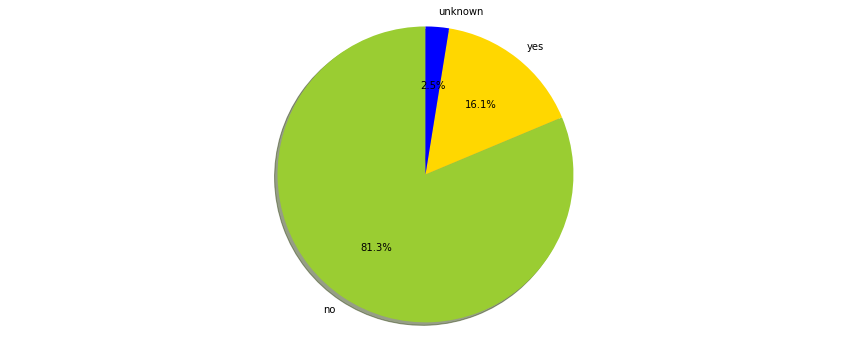

In [12]:
# Loanの分布を図で表す
# 要素名の取り出し
labels = bank_data_math['loan'].value_counts().index

# 男女別人数の取り出し
sizes = bank_data_math['loan'].value_counts().values

# グラフの色の指定（任意）
colors = ['yellowgreen', 'gold','blue']

# グラフの大きさ指定
plt.figure(figsize = (15, 6))

# グラフを描画
plt.pie(sizes, labels = labels, colors = colors,
        autopct = '%1.1f%%', shadow = True, startangle = 90)

# 円を丸く描画
plt.axis('equal')

### 3.消費者信頼指数の最大値、最小値、平均値、中央値、最頻値を求めましょう

In [13]:
# 最大値
print('最大値:', bank_data_math['cons.conf.idx'].max())

最大値: -26.9


In [14]:
# 最小値
print('最小値:', bank_data_math['cons.conf.idx'].min())

最小値: -50.8


In [15]:
# 平均値
print('平均値:', bank_data_math['cons.conf.idx'].mean())

平均値: -40.499101723719384


In [16]:
# 中央値
print('中央値:', bank_data_math['cons.conf.idx'].median())

中央値: -41.8


In [17]:
# 最頻値(Seriesオブジェクトで返ってくることに注意)
print('最頻値:', bank_data_math['cons.conf.idx'].mode())

最頻値: 0   -36.4
dtype: float64


### 4.消費者信頼指数と消費者物価指数の間にある関係性を調べましょう

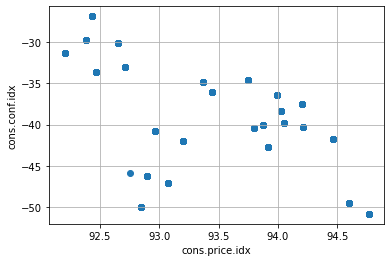

In [18]:
# 散布図
plt.scatter(bank_data_math['cons.price.idx'], bank_data_math['cons.conf.idx'])

# ラベル
plt.ylabel('cons.conf.idx')
plt.xlabel('cons.price.idx')
plt.grid(True)

In [19]:
# 相関係数
sp.stats.pearsonr(bank_data_math['cons.price.idx'], bank_data_math['cons.conf.idx'])

(0.04583497883978053, 0.003257667159446148)